LATEST ONE

In [3]:
import os
import time
from dataclasses import dataclass, asdict
from typing import List, Tuple, Optional, Dict, Any, Union

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm


# ----------------------------- Utilities --------------------------------------
def set_seed(seed: int = 42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def one_hot(y: torch.Tensor, num_classes: int) -> torch.Tensor:
    return F.one_hot(y.long(), num_classes=num_classes).float()


def default_device():
    return "cuda" if torch.cuda.is_available() else "cpu"

# -------------------------- Dataset Wrapper -----------------------------------
class CaltechFacesMotorbikes(Dataset):
    def __init__(self, root: str, transform=None, download: bool = True):
        # We use Caltech101 which contains Faces and Motorbikes
        self.ds = datasets.Caltech101(root=root, download=download, transform=transform)

        # Map string categories to indices
        cat_to_idx = {cat: i for i, cat in enumerate(self.ds.categories)}

        # 'Faces_easy' or 'Faces' are available in Caltech101
        faces_cat = 'Faces_easy' if 'Faces_easy' in cat_to_idx else 'Faces'
        allowed_labels = [cat_to_idx[faces_cat], cat_to_idx['Motorbikes']]

        self.indices = []
        self.labels = []

        # Filter only the two classes
        for i, target in enumerate(self.ds.y):
            if target in allowed_labels:
                self.indices.append(i)
                # Map Faces to 0, Motorbikes to 1
                self.labels.append(0 if target == allowed_labels[0] else 1)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, _ = self.ds[real_idx]
        return img, self.labels[idx]

def get_loaders_with_val(
    batch_size: int = 32,
    root: str = "./data",
    dataset_name: str = "CALTECH",
    device: str = "cpu",
    val_ratio: float = 0.1,
    test_ratio: float = 0.2,
    seed: int = 42,
):
    # Standardize image size and channels for Caltech
    tfm = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor()
    ])

    full_ds = CaltechFacesMotorbikes(root=root, transform=tfm, download=True)

    n_total = len(full_ds)
    n_val = max(1, int(round(val_ratio * n_total)))
    n_test = max(1, int(round(test_ratio * n_total)))
    n_train = n_total - n_val - n_test

    g = torch.Generator().manual_seed(seed)
    train_ds, val_ds, test_ds = random_split(full_ds, [n_train, n_val, n_test], generator=g)

    use_cuda = (str(device).startswith("cuda") and torch.cuda.is_available())
    num_workers = 2 if use_cuda else 0
    pin_memory = True if use_cuda else False

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=pin_memory,
        persistent_workers=(num_workers > 0)
    )
    train_eval_loader = DataLoader(output_ds:=train_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=pin_memory,
        persistent_workers=(num_workers > 0)
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=pin_memory,
        persistent_workers=(num_workers > 0)
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=pin_memory,
        persistent_workers=(num_workers > 0)
    )
    return train_loader, train_eval_loader, val_loader, test_loader


# ----------------------------- Metrics (fast, no sklearn) ---------------------
class MetricAccumulator:
    def __init__(self, num_classes: int, device: str = "cpu"):
        self.C = int(num_classes)
        self.device = device
        self.reset()

    def reset(self):
        self.tp = torch.zeros(self.C, dtype=torch.long, device=self.device)
        self.fp = torch.zeros(self.C, dtype=torch.long, device=self.device)
        self.fn = torch.zeros(self.C, dtype=torch.long, device=self.device)
        self.correct = 0
        self.total = 0

    @torch.no_grad()
    def update(self, pred: torch.Tensor, y: torch.Tensor):
        pred = pred.view(-1).long()
        y = y.view(-1).long()
        B = y.numel()
        self.total += int(B)
        self.correct += int((pred == y).sum().item())
        pred_count = torch.bincount(pred, minlength=self.C)
        true_count = torch.bincount(y, minlength=self.C)
        tp = torch.bincount(pred[pred == y], minlength=self.C)
        fp = pred_count - tp
        fn = true_count - tp
        self.tp += tp
        self.fp += fp
        self.fn += fn

    @torch.no_grad()
    def compute(self, eps: float = 1e-8) -> Dict[str, float]:
        tp = self.tp.float()
        fp = self.fp.float()
        fn = self.fn.float()
        precision_c = tp / (tp + fp + eps)
        recall_c = tp / (tp + fn + eps)
        f1_c = 2.0 * precision_c * recall_c / (precision_c + recall_c + eps)
        acc = float(self.correct / max(self.total, 1))
        precision = float(precision_c.mean().item())
        recall = float(recall_c.mean().item())
        f1 = float(f1_c.mean().item())
        return {"acc": acc, "precision": precision, "recall": recall, "f1": f1}


def _pretty_metrics(m: Dict[str, float]) -> str:
    return f"Acc {m['acc']:.4f} | P {m['precision']:.4f} | R {m['recall']:.4f} | F1 {m['f1']:.4f}"


# ------------------ Activations for PC ----------------------------------------
def make_pc_activation(name: str):
    name = name.lower()
    if name == "sigmoid":
        f = torch.sigmoid
        fprime = lambda z: torch.sigmoid(z) * (1 - torch.sigmoid(z))
        return f, fprime
    if name == "tanh":
        f = torch.tanh
        fprime = lambda z: 1 - torch.tanh(z) ** 2
        return f, fprime
    if name == "relu":
        def f(z): return torch.clamp(z, 0.0, 1.0)
        def fprime(z): return ((z > 0.0) & (z < 1.0)).float()
        return f, fprime
    return (lambda z: z), (lambda z: torch.ones_like(z))


# ============================================================
# HH NEURON (stabilized)
# ============================================================
class HHNeuron(nn.Module):
    class Gate:
        def __init__(self, B, N, device="cpu"):
            self.alpha = torch.zeros(B, N, device=device)
            self.beta  = torch.zeros(B, N, device=device)
            self.state = torch.zeros(B, N, device=device)

        def update(self, dt):
            a = self.alpha * (1.0 - self.state)
            b = self.beta  * self.state
            s = self.state + dt * (a - b)
            return torch.clamp(s, 0.0, 1.0)

        def set_inf(self):
            self.state = self.alpha / (self.alpha + self.beta + 1e-8)

    def __init__(self, N, dt=0.03, device="cpu", thr=10.0, reset=0.0, tau_ref=2.0):
        super().__init__()
        self.N = N
        self.dt = float(dt)
        self.device = device
        self.thr = float(thr)
        self.reset = float(reset)
        self.tau_ref = float(tau_ref)
        self.ENa   = nn.Parameter(torch.tensor(115.0), requires_grad=False)
        self.EK    = nn.Parameter(torch.tensor(-12.0), requires_grad=False)
        self.Eleak = nn.Parameter(torch.tensor(10.6),  requires_grad=False)
        self.gNa   = nn.Parameter(torch.tensor(120.0), requires_grad=False)
        self.gK    = nn.Parameter(torch.tensor(36.0),  requires_grad=False)
        self.gLeak = nn.Parameter(torch.tensor(0.3),   requires_grad=False)
        self.Cm    = nn.Parameter(torch.tensor(1.0),   requires_grad=False)
        self.reset_states(B=1)

    def reset_states(self, B: int):
        dev = self.device
        self.B = B
        self.Vm = torch.zeros(B, self.N, device=dev)
        self.m = HHNeuron.Gate(B, self.N, dev)
        self.n = HHNeuron.Gate(B, self.N, dev)
        self.h = HHNeuron.Gate(B, self.N, dev)
        self._update_gates(self.Vm)
        self.m.set_inf()
        self.n.set_inf()
        self.h.set_inf()
        self.refr = torch.zeros(B, self.N, device=dev)
        self.refr_steps = max(1, int(round(self.tau_ref / self.dt)))

    def _update_gates(self, V):
        V = torch.clamp(V, -100.0, 100.0)
        self.n.alpha = 0.01 * (10.0 - V) / (torch.exp((10.0 - V) / 10.0) - 1.0 + 1e-8)
        self.n.beta  = 0.125 * torch.exp(-V / 80.0)
        self.m.alpha = 0.1 * (25.0 - V) / (torch.exp((25.0 - V) / 10.0) - 1.0 + 1e-8)
        self.m.beta  = 4.0 * torch.exp(-V / 18.0)
        self.h.alpha = 0.07 * torch.exp(-V / 20.0)
        self.h.beta  = 1.0 / (torch.exp((30.0 - V) / 10.0) + 1.0)

    def _currents(self, V, I, m, n, h):
        INa = (m**3) * self.gNa * h * (V - self.ENa)
        IK  = (n**4) * self.gK      * (V - self.EK)
        Ile = self.gLeak * (V - self.Eleak)
        return I - INa - IK - Ile

    def forward(self, I: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        if I.shape[0] != getattr(self, "B", None):
            self.reset_states(B=I.shape[0])
        self._update_gates(self.Vm)
        m = self.m.update(self.dt)
        n = self.n.update(self.dt)
        h = self.h.update(self.dt)
        dV = self._currents(self.Vm, I, m, n, h) / self.Cm
        Vn = self.Vm + self.dt * dV
        v_cap = 30.0
        Vn = torch.tanh(Vn / v_cap) * v_cap
        can = (self.refr <= 0)
        spk = ((Vn >= self.thr) & can).float()
        self.Vm = torch.where(spk.bool(), torch.full_like(Vn, self.reset), Vn)
        self.m.state = m
        self.n.state = n
        self.h.state = h
        self.refr = torch.where(spk.bool(), torch.full_like(self.refr, float(self.refr_steps)), torch.clamp(self.refr - 1.0, min=0.0))
        return spk, self.Vm


# ============================================================
# LIF NEURON
# ============================================================
class LIFNeuron(nn.Module):
    def __init__(self, N, dt=0.03, device="cpu", thr=1.0, reset=0.0, tau=0.3, tau_ref=2.0):
        super().__init__()
        self.N = N
        self.dt = float(dt)
        self.device = device
        self.thr = float(thr)
        self.reset = float(reset)
        self.tau = float(tau)
        self.tau_ref = float(tau_ref)
        self.reset_states(B=1)

    def reset_states(self, B: int):
        self.B = B
        self.Vm = torch.zeros(B, self.N, device=self.device)
        self.refr = torch.zeros(B, self.N, device=self.device)
        self.refr_steps = max(1, int(round(self.tau_ref / self.dt)))

    def forward(self, I: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        if I.shape[0] != getattr(self, "B", None):
            self.reset_states(B=I.shape[0])
        can = (self.refr <= 0)
        dV = (-self.Vm + I) * (self.dt / max(self.tau, 1e-6))
        Vn = self.Vm + dV
        spk = ((Vn >= self.thr) & can).float()
        self.Vm = torch.where(spk.bool(), torch.full_like(Vn, self.reset), Vn)
        self.refr = torch.where(spk.bool(), torch.full_like(self.refr, float(self.refr_steps)), torch.clamp(self.refr - 1.0, min=0.0))
        return spk, self.Vm


# ============================================================
# HH-PC NETWORK
# ============================================================
class PCSNNetHH(nn.Module):
    def __init__(self, layer_sizes: List[int], dt=0.03, device="cuda", current_gain: Union[float, List[float]] = 30.0, I_bias: Union[float, List[float]] = 2.0, hh_thr: Union[float, List[float]] = 0.8, pc_activation: str = "relu", lr: float = 2e-4, weight_decay: float = 1e-4, input_encoding: str = "poisson", poisson_scale: float = 1.0, precompute_poisson: bool = True):
        super().__init__()
        self.device = torch.device(device)
        self.sizes = layer_sizes
        self.dt = float(dt)
        self.input_encoding = input_encoding.lower()
        self.poisson_scale = float(poisson_scale)
        self.precompute_poisson = bool(precompute_poisson)
        self.f, self.fprime = make_pc_activation(pc_activation)
        self.L = len(layer_sizes) - 1
        self.S = self.L
        self.syn = nn.ModuleList([nn.Linear(layer_sizes[i], layer_sizes[i + 1], bias=True) for i in range(self.L)])
        for lin in self.syn:
            nn.init.xavier_uniform_(lin.weight, gain=0.5)
            nn.init.zeros_(lin.bias)
        def _as_list(v, n, name):
            if isinstance(v, (list, tuple)):
                if len(v) == 1: return [float(v[0])] * n
                return [float(x) for x in v]
            return [float(v)] * n
        self.current_gain = _as_list(current_gain, self.S, "current_gain")
        self.I_bias       = _as_list(I_bias,       self.S, "I_bias")
        self.hh_thr       = _as_list(hh_thr,       self.S, "hh_thr")
        self.hh = nn.ModuleList()
        for i in range(self.S):
            self.hh.append(HHNeuron(layer_sizes[i + 1], dt=dt, device=self.device, thr=self.hh_thr[i]))
        self.opt = torch.optim.Adam(self.syn.parameters(), lr=lr, weight_decay=weight_decay)
        self._last_spike_sums: Optional[List[torch.Tensor]] = None

    @torch.no_grad()
    def forward_proxies(self, x_in_intensity: torch.Tensor, steps_spk: int) -> List[torch.Tensor]:
        B = x_in_intensity.shape[0]
        x0 = x_in_intensity.to(self.device).clamp(0, 1)
        for cell in self.hh: cell.reset_states(B)
        p = (x0 * self.poisson_scale).clamp(0.0, 1.0)
        poisson_spikes = (torch.rand(B, x0.size(1), steps_spk, device=self.device) < p.unsqueeze(-1)).float()
        spike_sums = [torch.zeros(B, self.sizes[i + 1], device=self.device) for i in range(self.S)]
        for t in range(steps_spk):
            r_prev = poisson_spikes[:, :, t]
            for i in range(self.S):
                h = F.linear(r_prev, self.syn[i].weight, self.syn[i].bias)
                I = h * self.current_gain[i] + self.I_bias[i]
                spk, _ = self.hh[i](I)
                spike_sums[i] += spk
                r_prev = spk
        self._last_spike_sums = spike_sums
        proxies = [x0]
        for i in range(self.S): proxies.append((spike_sums[i] / float(steps_spk)).clamp(0.0, 1.0))
        return proxies

    def pc_infer(self, x_init: List[torch.Tensor], y_target: Optional[torch.Tensor] = None, T_infer: int = 50, eta_x: float = 0.05, clamp_output: bool = True):
        L = self.L
        x = [xi.clone().detach().to(self.device) for xi in x_init]
        if clamp_output and (y_target is not None): x[L] = y_target.clone().detach().to(self.device).clamp(0, 1)
        z_cache = [None] * L
        for _ in range(T_infer):
            e = [None] * (L + 1)
            for l in range(1, L + 1):
                idx = l - 1
                z = F.linear(x[l - 1], self.syn[idx].weight, self.syn[idx].bias)
                z_cache[idx] = z
                e[l] = x[l] - self.f(z)
            for l in range(1, L):
                idx_dn = l
                downstream = (e[l + 1] * self.fprime(z_cache[idx_dn])) @ self.syn[idx_dn].weight
                x[l] = (x[l] - eta_x * (e[l] - downstream)).clamp_(0.0, 1.0)
            if not clamp_output: x[L] = (x[L] - eta_x * e[L]).clamp_(0.0, 1.0)
        energy = 0.0
        for l in range(1, L + 1):
            z = F.linear(x[l-1], self.syn[l-1].weight, self.syn[l-1].bias)
            energy += 0.5 * ((x[l] - self.f(z))**2).mean().item()
        return x, e, z_cache, energy

    def pc_learn(self, x: List[torch.Tensor], e: List[torch.Tensor], z_cache: List[torch.Tensor]):
        self.opt.zero_grad()
        B = x[0].shape[0]
        for idx in range(self.L):
            local = e[idx + 1] * self.fprime(z_cache[idx])
            self.syn[idx].weight.grad = - (local.T @ x[idx]) / B
            self.syn[idx].bias.grad = - local.mean(dim=0)
        torch.nn.utils.clip_grad_norm_(self.syn.parameters(), max_norm=1.0)
        self.opt.step()

    def train_step(self, x_in: torch.Tensor, y_target: torch.Tensor, steps_spk: int, T_infer: int, eta_x: float):
        proxies = self.forward_proxies(x_in, steps_spk=steps_spk)
        x, e, z_cache, energy = self.pc_infer(proxies, y_target=y_target, T_infer=T_infer, eta_x=eta_x, clamp_output=True)
        self.pc_learn(x, e, z_cache)
        return energy, proxies


# ============================================================
# LIF-PC NETWORK
# ============================================================
class PCSNNetLIF(nn.Module):
    def __init__(self, layer_sizes: List[int], dt=0.03, device="cuda", current_gain: Union[float, List[float]] = 30.0, I_bias: Union[float, List[float]] = 2.0, lif_thr: Union[float, List[float]] = 0.8, lif_tau: float = 0.3, pc_activation: str = "relu", lr: float = 2e-4, weight_decay: float = 1e-4, input_encoding: str = "poisson", poisson_scale: float = 1.0, precompute_poisson: bool = True):
        super().__init__()
        self.device = torch.device(device)
        self.sizes = layer_sizes
        self.dt = float(dt)
        self.input_encoding = input_encoding.lower()
        self.poisson_scale = float(poisson_scale)
        self.precompute_poisson = bool(precompute_poisson)
        self.f, self.fprime = make_pc_activation(pc_activation)
        self.L = len(layer_sizes) - 1
        self.S = self.L
        self.syn = nn.ModuleList([nn.Linear(layer_sizes[i], layer_sizes[i + 1], bias=True) for i in range(self.L)])
        for lin in self.syn:
            nn.init.xavier_uniform_(lin.weight, gain=0.5)
            nn.init.zeros_(lin.bias)
        def _as_list(v, n, name):
            if isinstance(v, (list, tuple)):
                if len(v) == 1: return [float(v[0])] * n
                return [float(x) for x in v]
            return [float(v)] * n
        self.current_gain = _as_list(current_gain, self.S, "current_gain")
        self.I_bias       = _as_list(I_bias,       self.S, "I_bias")
        self.lif_thr      = _as_list(lif_thr,      self.S, "lif_thr")
        self.cells = nn.ModuleList()
        for i in range(self.S):
            self.cells.append(LIFNeuron(layer_sizes[i + 1], dt=self.dt, device=self.device, thr=self.lif_thr[i], tau=lif_tau))
        self.opt = torch.optim.Adam(self.syn.parameters(), lr=lr, weight_decay=weight_decay)
        self._last_spike_sums: Optional[List[torch.Tensor]] = None

    @torch.no_grad()
    def forward_proxies(self, x_in_intensity: torch.Tensor, steps_spk: int) -> List[torch.Tensor]:
        x0 = x_in_intensity.to(self.device).clamp(0, 1)
        B = x0.size(0)
        for cell in self.cells: cell.reset_states(B)
        p = (x0 * self.poisson_scale).clamp(0.0, 1.0)
        poisson_spikes = (torch.rand(B, x0.size(1), steps_spk, device=self.device) < p.unsqueeze(-1)).float()
        spike_sums = [torch.zeros(B, self.sizes[i + 1], device=self.device) for i in range(self.S)]
        for t in range(steps_spk):
            r_prev = poisson_spikes[:, :, t]
            for i in range(self.S):
                h = F.linear(r_prev, self.syn[i].weight, self.syn[i].bias)
                I = h * self.current_gain[i] + self.I_bias[i]
                spk, _ = self.cells[i](I)
                spike_sums[i] += spk
                r_prev = spk
        self._last_spike_sums = spike_sums
        proxies = [x0]
        for i in range(self.S): proxies.append((spike_sums[i] / float(steps_spk)).clamp(0.0, 1.0))
        return proxies

    def pc_infer(self, x_init: List[torch.Tensor], y_target: Optional[torch.Tensor] = None, T_infer: int = 50, eta_x: float = 0.05, clamp_output: bool = True):
        L = self.L
        x = [xi.clone().detach().to(self.device) for xi in x_init]
        if clamp_output and (y_target is not None): x[L] = y_target.clone().detach().to(self.device).clamp(0, 1)
        z_cache = [None] * L
        for _ in range(T_infer):
            e = [None] * (L + 1)
            for l in range(1, L + 1):
                idx = l - 1
                z = F.linear(x[l - 1], self.syn[idx].weight, self.syn[idx].bias)
                z_cache[idx] = z
                e[l] = x[l] - self.f(z)
            for l in range(1, L):
                idx_dn = l
                downstream = (e[l + 1] * self.fprime(z_cache[idx_dn])) @ self.syn[idx_dn].weight
                x[l] = (x[l] - eta_x * (e[l] - downstream)).clamp_(0.0, 1.0)
            if not clamp_output: x[L] = (x[L] - eta_x * e[L]).clamp_(0.0, 1.0)
        energy = 0.0
        for l in range(1, L + 1):
            z = F.linear(x[l-1], self.syn[l-1].weight, self.syn[l-1].bias)
            energy += 0.5 * ((x[l] - self.f(z))**2).mean().item()
        return x, e, z_cache, energy

    def pc_learn(self, x: List[torch.Tensor], e: List[torch.Tensor], z_cache: List[torch.Tensor]):
        self.opt.zero_grad()
        B = x[0].shape[0]
        for idx in range(self.L):
            local = e[idx + 1] * self.fprime(z_cache[idx])
            self.syn[idx].weight.grad = - (local.T @ x[idx]) / B
            self.syn[idx].bias.grad = - local.mean(dim=0)
        torch.nn.utils.clip_grad_norm_(self.syn.parameters(), max_norm=1.0)
        self.opt.step()

    def train_step(self, x_in: torch.Tensor, y_target: torch.Tensor, steps_spk: int, T_infer: int, eta_x: float):
        proxies = self.forward_proxies(x_in, steps_spk=steps_spk)
        x, e, z_cache, energy = self.pc_infer(proxies, y_target=y_target, T_infer=T_infer, eta_x=eta_x, clamp_output=True)
        self.pc_learn(x, e, z_cache)
        return energy, proxies


# ============================================================
# Evaluation & Training Loop
# ============================================================
@torch.no_grad()
def spike_rate_epoch_any(model, loader, device: str, steps_spk: int, eval_seed: int = 1234):
    model.eval()
    S = model.S
    total_spikes = [0.0] * S
    total_denom = [0.0] * S
    torch.manual_seed(eval_seed)
    for x, _ in loader:
        x = x.to(device).view(x.size(0), -1)
        model.forward_proxies(x, steps_spk=steps_spk)
        spike_sums = model._last_spike_sums
        for i in range(S):
            total_spikes[i] += spike_sums[i].sum().item()
            total_denom[i] += x.size(0) * model.sizes[i+1] * steps_spk
    return [total_spikes[i] / max(total_denom[i], 1.0) for i in range(S)]

@torch.no_grad()
def eval_epoch_any(model, loader, device: str, steps_spk: int, T_infer: int, eta_x: float, eval_mode: str = "pc", eval_seed: int = 1234):
    model.eval()
    accum = MetricAccumulator(model.sizes[-1], device="cpu")
    total_energy = 0.0
    count = 0
    torch.manual_seed(eval_seed)
    for x, y in loader:
        x = x.to(device).view(x.size(0), -1)
        y = y.to(device)
        proxies = model.forward_proxies(x, steps_spk=steps_spk)
        if eval_mode == "pc":
            x_s, _, _, _ = model.pc_infer(proxies, y_target=None, T_infer=T_infer, eta_x=eta_x, clamp_output=False)
            pred = x_s[-1].argmax(dim=1)
        else:
            pred = proxies[-1].argmax(dim=1)
        accum.update(pred.cpu(), y.cpu())
        _, _, _, e = model.pc_infer(proxies, y_target=one_hot(y, model.sizes[-1]), T_infer=T_infer, eta_x=eta_x, clamp_output=True)
        total_energy += e * x.size(0)
        count += x.size(0)
    metrics = accum.compute()
    metrics["pc_energy"] = total_energy / max(count, 1)
    return metrics

@dataclass
class Cfg:
    dataset: str = "CALTECH"
    # 64x64 input (4096), 512 hidden, 2 output classes (Faces vs Motorbikes)
    layer_sizes: Tuple[int, int, int] = (4096, 512, 2)
    steps_spk: int = 20
    input_encoding: str = "poisson"
    poisson_scale: float = 1.0
    current_gain: float = 30.0
    I_bias: float = 2.0
    thr: float = 0.8
    lif_tau: float = 0.3
    pc_activation: str = "relu"
    lr: float = 2e-4
    weight_decay: float = 1e-4
    T_infer_train: int = 100
    T_infer_eval: int = 50
    eta_x: float = 0.05
    epochs: int = 5
    batch_size: int = 32 # Lowered for smaller Caltech dataset
    eval_seed: int = 1234
    eval_mode: str = "pc"
    ckpt_hh: str = "best_HH_PC.pt"
    ckpt_lif: str = "best_LIF_PC.pt"

def train_model_any(model, train_loader, val_loader, device: str, cfg: Cfg, ckpt_path: str, name: str):
    hist = {"train_energy": [], "val_mode": [], "val_spike_rate": []}
    best_acc = 0.0
    print(f"\n--- Training {name} ---")
    for epoch in range(1, cfg.epochs + 1):
        model.train()
        e_sum, count = 0.0, 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}")
        for x, y in pbar:
            x, y = x.to(device).view(x.size(0), -1), y.to(device)
            e, _ = model.train_step(x, one_hot(y, cfg.layer_sizes[-1]), cfg.steps_spk, cfg.T_infer_train, cfg.eta_x)
            e_sum += e * x.size(0); count += x.size(0)
            pbar.set_postfix({"E": f"{e:.4f}"})
        val_stats = eval_epoch_any(model, val_loader, device, cfg.steps_spk, cfg.T_infer_eval, cfg.eta_x, cfg.eval_mode, cfg.eval_seed)
        val_rates = spike_rate_epoch_any(model, val_loader, device, cfg.steps_spk, cfg.eval_seed)
        hist["train_energy"].append(e_sum/count)
        hist["val_mode"].append(val_stats)
        hist["val_spike_rate"].append(val_rates)
        print(f"Val Acc: {val_stats['acc']:.4f} | Rates: {val_rates}")
        if val_stats["acc" ] > best_acc:
            best_acc = val_stats["acc"]
            torch.save(model.state_dict(), ckpt_path)
    if os.path.exists(ckpt_path): model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return hist

if __name__ == "__main__":
    set_seed(42)
    device = default_device()
    cfg = Cfg()
    train_loader, _, val_loader, test_loader = get_loaders_with_val(batch_size=cfg.batch_size, device=device)

    hh_model = PCSNNetHH(list(cfg.layer_sizes), device=device).to(device)
    lif_model = PCSNNetLIF(list(cfg.layer_sizes), device=device).to(device)

    hh_hist = train_model_any(hh_model, train_loader, val_loader, device, cfg, cfg.ckpt_hh, "HH-PC")
    lif_hist = train_model_any(lif_model, train_loader, val_loader, device, cfg, cfg.ckpt_lif, "LIF-PC")

    # Evaluate on Test Set
    hh_test_metrics = eval_epoch_any(hh_model, test_loader, device, cfg.steps_spk, cfg.T_infer_eval, cfg.eta_x, cfg.eval_mode, cfg.eval_seed)
    lif_test_metrics = eval_epoch_any(lif_model, test_loader, device, cfg.steps_spk, cfg.T_infer_eval, cfg.eta_x, cfg.eval_mode, cfg.eval_seed)

    def calculate_comparison(hh_hist, lif_hist, hh_test, lif_test):
        # Extract final validation metrics
        hh_final_rates = hh_hist['val_spike_rate'][-1]
        lif_final_rates = lif_hist['val_spike_rate'][-1]

        hh_avg_rate = sum(hh_final_rates) / len(hh_final_rates)
        lif_avg_rate = sum(lif_final_rates) / len(lif_final_rates)

        hh_final_energy = hh_hist['train_energy'][-1]
        lif_final_energy = lif_hist['train_energy'][-1]

        # Reductions
        rate_reduction = (1 - (hh_avg_rate / lif_avg_rate)) * 100
        energy_reduction = (1 - (hh_final_energy / lif_final_energy)) * 100

        print(f"\n--- Final Test Metrics ---")
        print(f"HH-PC  Test Acc: {hh_test['acc']:.4f} | Test F1: {hh_test['f1']:.4f}")
        print(f"LIF-PC Test Acc: {lif_test['acc']:.4f} | Test F1: {lif_test['f1']:.4f}")

        print(f"\n--- Spike Rate Analysis ---")
        print(f"HH Average Spike Rate:  {hh_avg_rate*100:.4f}%")
        print(f"LIF Average Spike Rate: {lif_avg_rate*100:.4f}%")
        print(f"Spike Rate Reduction (HH vs LIF): {rate_reduction:.2f}%")

        print(f"\n--- Energy Consumption Analysis ---")
        print(f"HH Final PC Energy:  {hh_final_energy:.6f}")
        print(f"LIF Final PC Energy: {lif_final_energy:.6f}")
        print(f"Energy Reduction (HH vs LIF): {energy_reduction:.2f}%")

    calculate_comparison(hh_hist, lif_hist, hh_test_metrics, lif_test_metrics)

100%|██████████| 137M/137M [00:07<00:00, 18.3MB/s]



--- Training HH-PC ---


Epoch 1: 100%|██████████| 27/27 [00:05<00:00,  4.91it/s, E=0.0025]


Val Acc: 0.9756 | Rates: [0.006068184705284553, 0.042682926829268296]


Epoch 2: 100%|██████████| 27/27 [00:03<00:00,  7.89it/s, E=0.0025]


...

Val Acc: 0.9837 | Rates: [0.003825266768292683, 0.05]


Epoch 4: 100%|██████████| 27/27 [00:02<00:00, 11.62it/s, E=0.0028]


Val Acc: 0.9837 | Rates: [0.004207952235772357, 0.05]


Epoch 5: 100%|██████████| 27/27 [00:02<00:00, 11.21it/s, E=0.0021]


Val Acc: 0.9837 | Rates: [0.004990790142276423, 0.05]

--- Final Test Metrics ---
HH-PC  Test Acc: 0.9960 | Test F1: 0.9957
LIF-PC Test Acc: 0.9838 | Test F1: 0.9826

--- Spike Rate Analysis ---
HH Average Spike Rate:  2.2877%
LIF Average Spike Rate: 2.7495%
Spike Rate Reduction (HH vs LIF): 16.80%

--- Energy Consumption Analysis ---
HH Final PC Energy:  0.002504
LIF Final PC Energy: 0.002977
Energy Reduction (HH vs LIF): 15.90%


In [5]:
# ============================================================
# SOP + FLOP CALCULATION FOR HH-PC AND LIF-PC
# ============================================================

def calculate_sop_flops(model, loader, device, steps_spk, T_infer,
                        eval_seed=1234):
    """
    SOP:
        Spike-driven synaptic operations.
        One presynaptic spike sent through one synapse = 1 SOP.

    FLOPs:
        Dense multiply-add operations in the predictive-coding loop.
        One multiply + one add = 2 FLOPs.

    Returns:
        dict containing spike rates, SOP/sample, FLOPs/sample,
        parameter count, and total test-set estimates.
    """

    model.eval()

    # --------------------------------------------------------
    # 1. Measure actual spike rates
    # --------------------------------------------------------
    torch.manual_seed(eval_seed)

    S = model.S

    # Spike rates of spiking layers
    total_spikes = [0.0] * S
    total_neurons_time = [0.0] * S

    # Input spike rate
    total_input_activity = 0.0
    total_input_elements = 0

    total_samples = 0

    with torch.no_grad():
        for x, _ in loader:

            x = x.to(device).view(x.size(0), -1)
            B = x.size(0)

            # Expected input Poisson spike probability
            # p = x * poisson_scale
            input_rate_batch = (
                x.clamp(0, 1) * model.poisson_scale
            ).clamp(0, 1).mean().item()

            total_input_activity += (
                input_rate_batch * B * x.size(1)
            )
            total_input_elements += B * x.size(1)

            # Generate hidden/output spike activity
            model.forward_proxies(
                x,
                steps_spk=steps_spk
            )

            spike_sums = model._last_spike_sums

            for i in range(S):
                total_spikes[i] += spike_sums[i].sum().item()

                total_neurons_time[i] += (
                    B
                    * model.sizes[i + 1]
                    * steps_spk
                )

            total_samples += B

    # --------------------------------------------------------
    # 2. Calculate spike rates
    # --------------------------------------------------------
    input_rate = (
        total_input_activity /
        max(total_input_elements, 1)
    )

    layer_rates = [
        total_spikes[i] /
        max(total_neurons_time[i], 1.0)
        for i in range(S)
    ]

    # --------------------------------------------------------
    # 3. SOP calculation
    #
    # Layer 0:
    # input spikes -> hidden neurons
    #
    # Layer 1:
    # hidden spikes -> output neurons
    #
    # SOP = spikes * fanout
    # --------------------------------------------------------

    sop_per_sample = 0.0

    for i in range(model.L):

        n_pre = model.sizes[i]
        n_post = model.sizes[i + 1]

        # Presynaptic firing rate
        if i == 0:
            pre_rate = input_rate
        else:
            pre_rate = layer_rates[i - 1]

        # Number of spike events in this layer/sample
        expected_spikes = (
            pre_rate
            * n_pre
            * steps_spk
        )

        # Every spike propagates to n_post synapses
        sop_layer = expected_spikes * n_post

        sop_per_sample += sop_layer

    # --------------------------------------------------------
    # 4. FLOPs for one PC inference iteration
    #
    # z = xW + b
    # Matrix multiplication:
    #     2 * N_in * N_out
    #
    # downstream:
    #     elementwise multiplication
    #     + matrix multiplication
    #
    # x update:
    #     several elementwise operations
    # --------------------------------------------------------

    flops_per_pc_iteration = 0.0

    for l in range(model.L):

        n_in = model.sizes[l]
        n_out = model.sizes[l + 1]

        # ----------------------------------------------------
        # z = F.linear(x, W, b)
        # ----------------------------------------------------
        flops_linear = 2 * n_in * n_out

        # Bias addition
        flops_bias = n_out

        flops_per_pc_iteration += (
            flops_linear + flops_bias
        )

    # --------------------------------------------------------
    # Downstream predictive-coding calculations
    #
    # for:
    #     l = 1 ... L-1
    #
    # downstream =
    #   (e[l+1] * f'(z)) @ W
    # --------------------------------------------------------

    for l in range(1, model.L):

        n_current = model.sizes[l]
        n_next = model.sizes[l + 1]

        # e * fprime(z)
        flops_elementwise = n_next

        # Matrix multiplication
        flops_matmul = (
            2 * n_next * n_current
        )

        flops_per_pc_iteration += (
            flops_elementwise +
            flops_matmul
        )

        # x[l] update:
        #
        # e - downstream
        # eta * (...)
        # x - ...
        #
        # Approximately 3 elementwise operations
        flops_x_update = 3 * n_current

        flops_per_pc_iteration += flops_x_update

    # --------------------------------------------------------
    # If output is not clamped, there would be an extra update.
    # In your evaluation/training code the output is normally
    # clamped for the learning energy pass.
    # --------------------------------------------------------

    # --------------------------------------------------------
    # 5. PC inference for T_infer iterations
    # --------------------------------------------------------

    flops_pc_inference = (
        flops_per_pc_iteration * T_infer
    )

    # --------------------------------------------------------
    # 6. Final energy calculation
    #
    # Your code performs one extra F.linear per layer:
    # z = F.linear(...)
    #
    # followed by subtraction, square, mean.
    # --------------------------------------------------------

    flops_energy = 0.0

    for l in range(model.L):

        n_in = model.sizes[l]
        n_out = model.sizes[l + 1]

        # Linear
        flops_energy += 2 * n_in * n_out

        # bias
        flops_energy += n_out

        # x - f(z)
        # square
        # multiply by 0.5
        flops_energy += 3 * n_out

    # --------------------------------------------------------
    # 7. Total FLOPs per sample
    # --------------------------------------------------------

    flops_per_sample = (
        flops_pc_inference +
        flops_energy
    )

    # --------------------------------------------------------
    # 8. Parameter count
    # --------------------------------------------------------

    param_count = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    # --------------------------------------------------------
    # 9. Total test-set estimates
    # --------------------------------------------------------

    total_sop = sop_per_sample * total_samples
    total_flops = flops_per_sample * total_samples

    return {
        "input_spike_rate": input_rate,
        "layer_spike_rates": layer_rates,

        "sop_per_sample": sop_per_sample,
        "total_sop": total_sop,

        "pc_flops_per_iteration": flops_per_pc_iteration,
        "pc_flops_per_sample": flops_per_sample,
        "total_flops": total_flops,

        "parameters": param_count,
        "samples": total_samples,
    }


# ============================================================
# RUN FOR HH-PC
# ============================================================

hh_complexity = calculate_sop_flops(
    model=hh_model,
    loader=test_loader,
    device=device,
    steps_spk=cfg.steps_spk,
    T_infer=cfg.T_infer_eval,
    eval_seed=cfg.eval_seed
)


# ============================================================
# RUN FOR LIF-PC
# ============================================================

lif_complexity = calculate_sop_flops(
    model=lif_model,
    loader=test_loader,
    device=device,
    steps_spk=cfg.steps_spk,
    T_infer=cfg.T_infer_eval,
    eval_seed=cfg.eval_seed
)


# ============================================================
# PRINT RESULTS
# ============================================================

print("\n" + "=" * 70)
print("COMPUTATIONAL COMPLEXITY")
print("=" * 70)

for name, result in [
    ("HH-PC", hh_complexity),
    ("LIF-PC", lif_complexity)
]:

    print(f"\n{name}")
    print("-" * 70)

    print(
        f"Input spike rate       : "
        f"{result['input_spike_rate']:.6f}"
    )

    for i, rate in enumerate(result["layer_spike_rates"]):
        print(
            f"Layer {i+1} spike rate      : "
            f"{rate:.6f}"
        )

    print(
        f"\nParameters             : "
        f"{result['parameters']:,}"
    )

    print(
        f"SOP / sample           : "
        f"{result['sop_per_sample']:,.0f}"
    )

    print(
        f"Total SOP (test set)   : "
        f"{result['total_sop']:,.0f}"
    )

    print(
        f"\nPC FLOPs / iteration   : "
        f"{result['pc_flops_per_iteration']:,.0f}"
    )

    print(
        f"Total FLOPs / sample   : "
        f"{result['pc_flops_per_sample']:,.0f}"
    )

    print(
        f"Total FLOPs (test set) : "
        f"{result['total_flops']:,.0f}"
    )


# ============================================================
# HH vs LIF COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("HH-PC vs LIF-PC")
print("=" * 70)

sop_reduction = (
    1 -
    hh_complexity["sop_per_sample"] /
    max(lif_complexity["sop_per_sample"], 1)
) * 100

flop_difference = (
    1 -
    hh_complexity["pc_flops_per_sample"] /
    max(lif_complexity["pc_flops_per_sample"], 1)
) * 100

print(
    f"\nHH SOP/sample : "
    f"{hh_complexity['sop_per_sample']:,.0f}"
)

print(
    f"LIF SOP/sample: "
    f"{lif_complexity['sop_per_sample']:,.0f}"
)

print(
    f"SOP reduction (HH vs LIF): "
    f"{sop_reduction:.2f}%"
)

print(
    f"\nHH FLOPs/sample : "
    f"{hh_complexity['pc_flops_per_sample']:,.0f}"
)

print(
    f"LIF FLOPs/sample: "
    f"{lif_complexity['pc_flops_per_sample']:,.0f}"
)

print(
    f"FLOP difference (HH vs LIF): "
    f"{flop_difference:.2f}%"
)


COMPUTATIONAL COMPLEXITY

HH-PC
----------------------------------------------------------------------
Input spike rate       : 0.598372
Layer 1 spike rate      : 0.005581
Layer 2 spike rate      : 0.040789

Parameters             : 2,098,690
SOP / sample           : 25,097,647
Total SOP (test set)   : 6,199,118,824

PC FLOPs / iteration   : 4,200,452
Total FLOPs / sample   : 214,221,008
Total FLOPs (test set) : 52,912,588,976

LIF-PC
----------------------------------------------------------------------
Input spike rate       : 0.598372
Layer 1 spike rate      : 0.003847
Layer 2 spike rate      : 0.050000

Parameters             : 2,098,690
SOP / sample           : 25,097,612
Total SOP (test set)   : 6,199,110,050

PC FLOPs / iteration   : 4,200,452
Total FLOPs / sample   : 214,221,008
Total FLOPs (test set) : 52,912,588,976

HH-PC vs LIF-PC

HH SOP/sample : 25,097,647
LIF SOP/sample: 25,097,612
SOP reduction (HH vs LIF): -0.00%

HH FLOPs/sample : 214,221,008
LIF FLOPs/sample: 214,22

--- HH-PC Evaluation ---


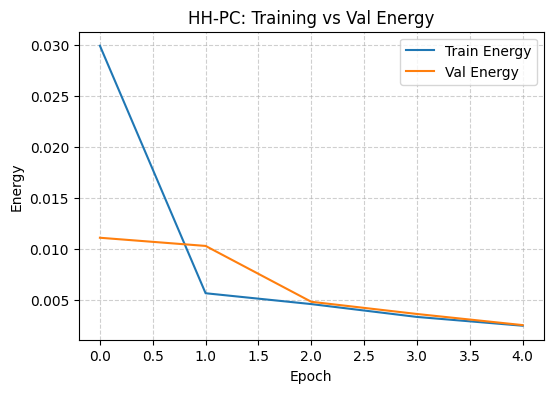

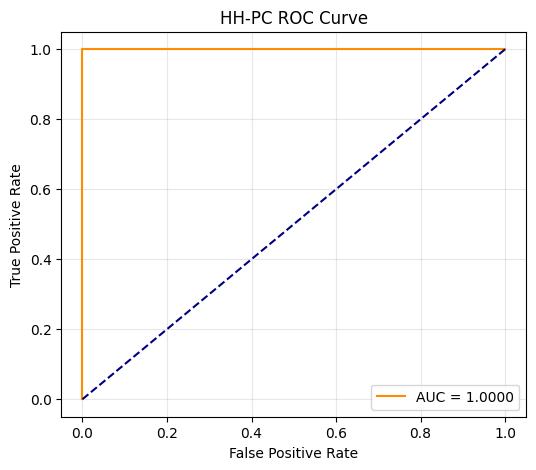

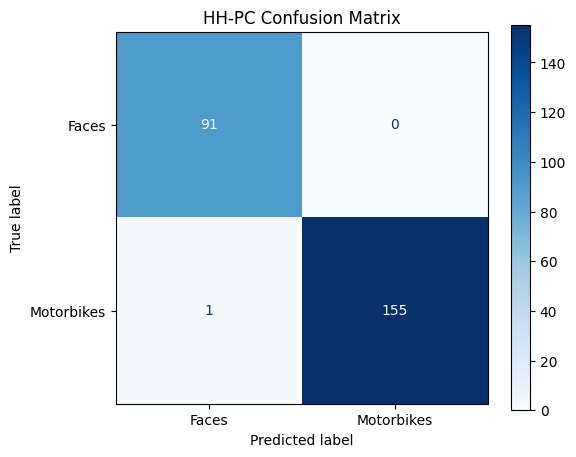

--- LIF-PC Evaluation ---


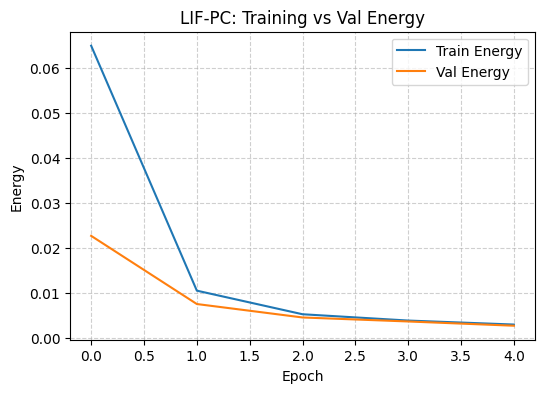

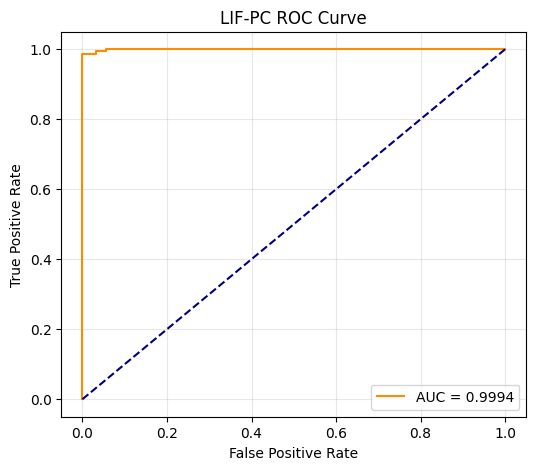

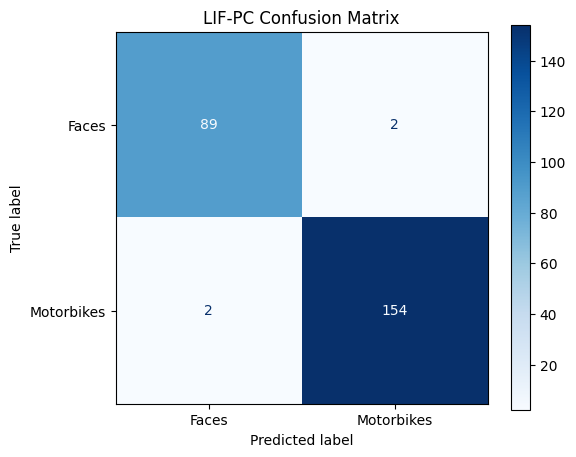


HH-PC  -> FLOPs: 67,141,632 | SOPs: 42,488,520
LIF-PC -> FLOPs: 67,141,632 | SOPs: 42,487,252


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import torch.nn.functional as F

def count_ops(model, x_in, steps_spk):
    flops = 0
    sops = 0
    model.eval()
    with torch.no_grad():
        proxies = model.forward_proxies(x_in, steps_spk)
        spike_sums = model._last_spike_sums
        for i, syn in enumerate(model.syn):
            flops += x_in.size(0) * syn.out_features * syn.in_features
            if i == 0:
                input_spikes = (x_in > 0.5).float().sum()
                sops += input_spikes * syn.out_features
            else:
                sops += spike_sums[i-1].sum() * syn.out_features
    return flops, int(sops.item())

def plot_energy_curve(hist, name):
    plt.figure(figsize=(6, 4))
    train_e = hist['train_energy']
    val_e = [m['pc_energy'] for m in hist['val_mode']]
    plt.plot(train_e, label='Train Energy')
    plt.plot(val_e, label='Val Energy')
    plt.title(f'{name}: Training vs Val Energy')
    plt.xlabel('Epoch')
    plt.ylabel('Energy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

def plot_performance_metrics(model, loader, device, cfg, name):
    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device).view(x.size(0), -1)
            proxies = model.forward_proxies(x, steps_spk=cfg.steps_spk)
            x_s, _, _, _ = model.pc_infer(proxies, T_infer=cfg.T_infer_eval, eta_x=cfg.eta_x, clamp_output=False)
            probs = F.softmax(x_s[-1], dim=1)[:, 1]
            preds = x_s[-1].argmax(dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y.numpy())
            all_preds.extend(preds.cpu().numpy())

    # 1. Separate ROC Curve Figure
    plt.figure(figsize=(6, 5))
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='darkorange', label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.title(f'{name} ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

    # 2. Separate Confusion Matrix Figure
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Faces', 'Motorbikes'])
    disp.plot(ax=ax, cmap='Blues', colorbar=True)
    plt.title(f'{name} Confusion Matrix')
    plt.show()

# Execution
print("--- HH-PC Evaluation ---")
plot_energy_curve(hh_hist, "HH-PC")
plot_performance_metrics(hh_model, test_loader, device, cfg, "HH-PC")

print("--- LIF-PC Evaluation ---")
plot_energy_curve(lif_hist, "LIF-PC")
plot_performance_metrics(lif_model, test_loader, device, cfg, "LIF-PC")

sample_x, _ = next(iter(test_loader))
sample_x = sample_x.to(device).view(sample_x.size(0), -1)
hh_f, hh_s = count_ops(hh_model, sample_x, cfg.steps_spk)
lif_f, lif_s = count_ops(lif_model, sample_x, cfg.steps_spk)
print(f"\nHH-PC  -> FLOPs: {hh_f:,} | SOPs: {hh_s:,}")
print(f"LIF-PC -> FLOPs: {lif_f:,} | SOPs: {lif_s:,}")